# 1. Project Overview

Notebook ini adalah pipeline submission **Dicoding Proyek Klasifikasi Gambar** untuk klasifikasi aset IT menggunakan **Open Images V7 detection crops**.

Dataset gambar sudah tersedia sebagai satu folder sumber `dataset/raw/<class_name>/`, yang dibuat menggunakan script Open Images di folder `src/`. Notebook ini kemudian membagi ulang dataset secara manual menjadi `train`, `validation`, dan `test` agar proses split dapat diverifikasi langsung oleh reviewer.

Model final pada notebook ini adalah `tf.keras.Sequential`, memiliki layer `Conv2D` eksplisit bernama `explicit_conv2d_requirement`, memiliki pooling layer eksplisit bernama `explicit_pooling_requirement`, dilatih dengan `model.fit()`, dievaluasi langsung dengan `model.evaluate(...)`, dan diexport ke SavedModel, TFLite, serta TensorFlow.js dari model yang sama.


# 2. Import Libraries

Bagian ini memuat library utama, konfigurasi reproducibility, dan perangkat komputasi yang tersedia. Seed `42` digunakan di Python, NumPy, dan TensorFlow.


In [1]:
from __future__ import annotations

import importlib.machinery
import json
import os
import random
import shutil
import sys
import types
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from PIL import Image, UnidentifiedImageError
from sklearn.metrics import classification_report, confusion_matrix

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))


2026-06-25 21:55:02.564305: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-25 21:55:02.577963: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782399302.596297    8961 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782399302.601327    8961 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782399302.615287    8961 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

TensorFlow: 2.19.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# 3. Reproducibility Setup dan Path

Semua path menggunakan relative path agar notebook tetap portabel. Folder `dataset/raw` adalah sumber gambar tunggal. Folder `dataset/submission_split` dibuat oleh notebook sebagai split manual reviewer-visible.


In [2]:
ROOT_DIR = Path(".")
CONFIG_PATH = ROOT_DIR / "configs" / "openimages_it_assets_classes.json"
RAW_DIR = ROOT_DIR / "dataset" / "raw"
METADATA_PATH = ROOT_DIR / "dataset" / "metadata" / "openimages_crop_metadata.csv"
SPLIT_METADATA_PATH = ROOT_DIR / "dataset" / "metadata" / "openimages_submission_split_metadata.csv"
SUBMISSION_SPLIT_DIR = ROOT_DIR / "dataset" / "submission_split"
TRAIN_DIR = SUBMISSION_SPLIT_DIR / "train"
VALIDATION_DIR = SUBMISSION_SPLIT_DIR / "validation"
TEST_DIR = SUBMISSION_SPLIT_DIR / "test"

OUTPUT_DIR = ROOT_DIR / "outputs"
DATASET_AUDIT_DIR = OUTPUT_DIR / "dataset_audit"
EVALUATION_DIR = OUTPUT_DIR / "evaluation"
EXPORT_DIR = OUTPUT_DIR / "export"
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints_sequential"
SAVED_MODEL_DIR = ROOT_DIR / "saved_model" / "it_asset_classifier"
TFLITE_DIR = ROOT_DIR / "tflite"
TFJS_MODEL_DIR = ROOT_DIR / "tfjs" / "it_asset_classifier"
TFJS_TEMP_SAVED_MODEL_DIR = EXPORT_DIR / "tfjs_it_asset_saved_model"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
TRAIN_RATIO = 0.80
VALIDATION_RATIO = 0.10
TEST_RATIO = 0.10
MINIMUM_REQUIRED_ACCURACY = 0.85
FIVE_STAR_TARGET_ACCURACY = 0.95
CLASSIFIER_NAME = "sequential_conv2d_pooling_it_asset_classifier"
REBUILD_SPLIT = True

for directory in [DATASET_AUDIT_DIR, EVALUATION_DIR, EXPORT_DIR, CHECKPOINT_DIR, TFLITE_DIR, TFJS_MODEL_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Raw source:", RAW_DIR)
print("Manual split output:", SUBMISSION_SPLIT_DIR)


Raw source: dataset/raw
Manual split output: dataset/submission_split


# 4. Dataset Source dan Script Acquisition

Gambar Open Images diperoleh menggunakan script Python yang disertakan pada folder `src/`. Notebook ini tidak mengunduh ulang gambar, tetapi memulai dari satu folder sumber `dataset/raw/<class_name>/` lalu melakukan pembagian manual menjadi train, validation, dan test agar proses split dapat diverifikasi langsung oleh reviewer.


In [3]:
required_acquisition_files = [
    ROOT_DIR / "src" / "build_openimages_subset.py",
    ROOT_DIR / "src" / "audit_openimages_subset.py",
    ROOT_DIR / "src" / "split_openimages_subset.py",
    ROOT_DIR / "src" / "audit_openimages_split.py",
    CONFIG_PATH,
]
acquisition_status = pd.DataFrame(
    [{"file": path.as_posix(), "exists": path.exists()} for path in required_acquisition_files]
)
acquisition_status


,file,exists
0,src/build_openimages_subset.py,True
1,src/audit_openimages_subset.py,True
2,src/split_openimages_subset.py,True
3,src/audit_openimages_split.py,True
4,configs/openimages_it_assets_classes.json,True


# 5. Dataset Metadata Validation

Kelas final dibaca dari `configs/openimages_it_assets_classes.json`. Metadata crop dari script acquisition dipakai untuk memastikan kelas aktif, jumlah gambar sumber, path gambar, `source_image_id`, dan `file_hash` tersedia sebelum split.


In [4]:
config = json.loads(CONFIG_PATH.read_text(encoding="utf-8"))
class_config = config["classes"]
class_names_from_config = [item["local_label"] for item in class_config]
openimages_labels = {item["local_label"]: item["openimages_label"] for item in class_config}

source_metadata = pd.read_csv(METADATA_PATH)
active_metadata = source_metadata[source_metadata["local_label"].isin(class_names_from_config)].copy()
active_metadata["crop_path"] = active_metadata["crop_path"].astype(str)
active_metadata["path_exists"] = active_metadata["crop_path"].map(lambda value: Path(value).is_file())

source_distribution = (
    active_metadata.groupby("local_label")
    .size()
    .reindex(class_names_from_config)
    .rename("source_count")
    .reset_index()
)
unused_raw_folders = sorted(
    path.name for path in RAW_DIR.iterdir()
    if path.is_dir() and path.name not in set(class_names_from_config)
)

metadata_validation = {
    "total_metadata_rows": int(len(source_metadata)),
    "active_source_images": int(len(active_metadata)),
    "class_count": int(len(class_names_from_config)),
    "class_names_from_config": class_names_from_config,
    "metadata_columns": list(source_metadata.columns),
    "missing_crop_path_count": int((~active_metadata["path_exists"]).sum()),
    "unused_raw_folders_not_in_final_config": unused_raw_folders,
}
print(json.dumps(metadata_validation, indent=2))
source_distribution


{
  "total_metadata_rows": 15000,
  "active_source_images": 15000,
  "class_count": 5,
  "class_names_from_config": [
    "laptop",
    "computer_keyboard",
    "mobile_phone",
    "computer_monitor",
    "camera"
  ],
  "metadata_columns": [
    "source_image_id",
    "source_split",
    "openimages_label",
    "local_label",
    "bbox_x",
    "bbox_y",
    "bbox_width",
    "bbox_height",
    "source_width",
    "source_height",
    "crop_width",
    "crop_height",
    "crop_path",
    "file_hash"
  ],
  "missing_crop_path_count": 0,
  "unused_raw_folders_not_in_final_config": [
    "computer_mouse",
    "headphones",
    "printer"
  ]
}


,local_label,source_count
0,laptop,3000
1,computer_keyboard,3000
2,mobile_phone,3000
3,computer_monitor,3000
4,camera,3000


# 6. Split Dataset Manual

Notebook membuat split manual dari `dataset/raw/<class_name>/` ke `dataset/submission_split/train|validation|test/<class_name>/` dengan rasio 80/10/10 dan seed `42`.

Jika metadata `source_image_id` tersedia, setiap source image diperlakukan sebagai group agar crop dari gambar sumber yang sama tidak tersebar ke split berbeda. Setelah split, notebook menghitung distribusi kelas, corrupt image count, duplicate hash antar split, dan menyimpan audit ke `outputs/dataset_audit/`.


In [5]:
SPLIT_NAMES = ["train", "validation", "test"]
RATIOS = {"train": TRAIN_RATIO, "validation": VALIDATION_RATIO, "test": TEST_RATIO}


def split_is_ready() -> bool:
    if REBUILD_SPLIT or not SPLIT_METADATA_PATH.exists():
        return False
    try:
        rows = pd.read_csv(SPLIT_METADATA_PATH)
    except Exception:
        return False
    required_columns = {"local_label", "local_split", "split_crop_path", "source_image_id", "file_hash"}
    if not required_columns.issubset(rows.columns):
        return False
    if len(rows) != len(active_metadata):
        return False
    sample_paths = rows["split_crop_path"].head(50).map(lambda value: Path(value).is_file())
    return bool(sample_paths.all())


def assign_groups_to_splits(metadata: pd.DataFrame) -> dict[str, str]:
    groups = {source_id: group for source_id, group in metadata.groupby("source_image_id", sort=True)}
    class_totals = Counter(metadata["local_label"])
    targets = {
        split_name: {label: class_totals[label] * ratio for label in class_names_from_config}
        for split_name, ratio in RATIOS.items()
    }
    current = {split_name: {label: 0 for label in class_names_from_config} for split_name in SPLIT_NAMES}
    group_label_counts = {source_id: Counter(group["local_label"]) for source_id, group in groups.items()}
    groups_by_label: dict[str, list[str]] = defaultdict(list)
    for source_id, label_counts in group_label_counts.items():
        for label in label_counts:
            groups_by_label[label].append(source_id)

    rng = random.Random(SEED)
    assignments: dict[str, str] = {}

    def choose_split(label_counts: Counter[str]) -> str:
        best_split = SPLIT_NAMES[0]
        best_score = None
        for split_index, split_name in enumerate(SPLIT_NAMES):
            overfill = 0.0
            remaining_after = 0.0
            for label, count in label_counts.items():
                target = targets[split_name][label]
                after = current[split_name][label] + count
                overfill += max(0.0, after - target)
                remaining_after += target - after
            score = (overfill, -remaining_after, split_index)
            if best_score is None or score < best_score:
                best_score = score
                best_split = split_name
        return best_split

    for label in class_names_from_config:
        source_ids = [source_id for source_id in groups_by_label[label] if source_id not in assignments]
        rng.shuffle(source_ids)
        for source_id in source_ids:
            label_counts = group_label_counts[source_id]
            split_name = choose_split(label_counts)
            assignments[source_id] = split_name
            for current_label, count in label_counts.items():
                current[split_name][current_label] += count

    for source_id in groups:
        if source_id in assignments:
            continue
        label_counts = group_label_counts[source_id]
        split_name = choose_split(label_counts)
        assignments[source_id] = split_name
        for current_label, count in label_counts.items():
            current[split_name][current_label] += count
    return assignments


def build_manual_split() -> pd.DataFrame:
    split_source = active_metadata.copy().sort_values(["local_label", "source_image_id", "crop_path"])
    if not split_source["path_exists"].all():
        missing = split_source.loc[~split_source["path_exists"], "crop_path"].head(10).tolist()
        raise FileNotFoundError(f"Missing crop_path files. Sample: {missing}")

    if SUBMISSION_SPLIT_DIR.exists():
        shutil.rmtree(SUBMISSION_SPLIT_DIR)
    for split_name in SPLIT_NAMES:
        for class_name in class_names_from_config:
            (SUBMISSION_SPLIT_DIR / split_name / class_name).mkdir(parents=True, exist_ok=True)

    def place_split_file(source_path: Path, target_path: Path) -> None:
        try:
            os.link(source_path, target_path)
        except OSError:
            shutil.copy2(source_path, target_path)

    assignments = assign_groups_to_splits(split_source)
    split_rows = []
    for row in split_source.to_dict("records"):
        split_name = assignments[row["source_image_id"]]
        source_path = Path(row["crop_path"])
        target_path = SUBMISSION_SPLIT_DIR / split_name / row["local_label"] / source_path.name
        place_split_file(source_path, target_path)
        split_row = {key: row[key] for key in source_metadata.columns if key in row}
        split_row["local_split"] = split_name
        split_row["split_crop_path"] = target_path.as_posix()
        split_rows.append(split_row)

    split_df = pd.DataFrame(split_rows)
    SPLIT_METADATA_PATH.parent.mkdir(parents=True, exist_ok=True)
    split_df.to_csv(SPLIT_METADATA_PATH, index=False)
    return split_df


if split_is_ready():
    split_metadata = pd.read_csv(SPLIT_METADATA_PATH)
    print(f"Manual split already available and validated: {SPLIT_METADATA_PATH}")
else:
    split_metadata = build_manual_split()
    print(f"Manual split rebuilt from dataset/raw: {SPLIT_METADATA_PATH}")

split_totals = split_metadata["local_split"].value_counts().reindex(SPLIT_NAMES).fillna(0).astype(int)
split_class_distribution = pd.crosstab(split_metadata["local_split"], split_metadata["local_label"]).reindex(index=SPLIT_NAMES, columns=class_names_from_config, fill_value=0)
print("Total source images:", len(active_metadata))
print("Class count:", len(class_names_from_config))
print("Split totals:")
print(split_totals.to_string())
split_class_distribution


Manual split rebuilt from dataset/raw: dataset/metadata/openimages_submission_split_metadata.csv
Total source images: 15000
Class count: 5
Split totals:
local_split
train         11998
validation     1504
test           1498


local_label,laptop,computer_keyboard,mobile_phone,computer_monitor,camera
local_split,,,,,
train,2399,2401,2400,2398,2400
validation,301,299,300,304,300
test,300,300,300,298,300


# 7. Dataset Audit

Audit ini dilakukan langsung dari metadata split dan file hasil split. Fokusnya adalah distribusi kelas, corrupt image count, duplicate hash antar split, format/mode/resolusi gambar, serta contoh gambar.


In [6]:
def validate_image_file(path: Path) -> dict[str, object]:
    try:
        with Image.open(path) as image:
            image.load()
            return {
                "ok": True,
                "format": image.format,
                "mode": image.mode,
                "resolution": f"{image.width}x{image.height}",
                "error": None,
            }
    except (OSError, UnidentifiedImageError) as error:
        return {"ok": False, "format": None, "mode": None, "resolution": None, "error": repr(error)}


image_audit_records = []
for path_text in split_metadata["split_crop_path"]:
    path = Path(path_text)
    result = validate_image_file(path)
    result["split_crop_path"] = path_text
    image_audit_records.append(result)
image_audit_df = pd.DataFrame(image_audit_records)

splits_by_hash = split_metadata.groupby("file_hash")["local_split"].nunique()
duplicate_hash_across_split = int((splits_by_hash > 1).sum())
duplicate_hash_total = int(split_metadata.duplicated("file_hash").sum())
splits_by_source = split_metadata.groupby("source_image_id")["local_split"].nunique()
source_image_leakage = int((splits_by_source > 1).sum())

split_summary_rows = []
for split_name in SPLIT_NAMES:
    row = {"split": split_name, "total": int(split_totals[split_name]), "ratio": float(split_totals[split_name] / len(split_metadata))}
    for class_name in class_names_from_config:
        row[class_name] = int(split_class_distribution.loc[split_name, class_name])
    split_summary_rows.append(row)
dataset_split_summary = pd.DataFrame(split_summary_rows)
dataset_split_summary.to_csv(DATASET_AUDIT_DIR / "dataset_split_summary.csv", index=False)

source_distribution.to_csv(DATASET_AUDIT_DIR / "source_class_distribution.csv", index=False)
image_audit_df.to_csv(DATASET_AUDIT_DIR / "dataset_file_audit.csv", index=False)

dataset_audit_summary = {
    "source_dir": RAW_DIR.as_posix(),
    "manual_split_dir": SUBMISSION_SPLIT_DIR.as_posix(),
    "seed": SEED,
    "split_ratio": RATIOS,
    "class_names": class_names_from_config,
    "total_source_images": int(len(active_metadata)),
    "split_totals": {key: int(value) for key, value in split_totals.items()},
    "class_distribution_before_split": dict(zip(source_distribution["local_label"], source_distribution["source_count"].astype(int))),
    "corrupt_image_count": int((~image_audit_df["ok"]).sum()),
    "duplicate_file_hash_count": duplicate_hash_total,
    "cross_split_duplicate_hash_count": duplicate_hash_across_split,
    "source_image_id_leakage_across_split_count": source_image_leakage,
    "image_formats": sorted(image_audit_df["format"].dropna().unique().tolist()),
    "image_modes": sorted(image_audit_df["mode"].dropna().unique().tolist()),
    "unique_resolutions_total": int(image_audit_df["resolution"].dropna().nunique()),
    "ready_for_modelling": bool((~image_audit_df["ok"]).sum() == 0 and duplicate_hash_across_split == 0 and source_image_leakage == 0),
}
(DATASET_AUDIT_DIR / "dataset_audit_summary.json").write_text(json.dumps(dataset_audit_summary, indent=2), encoding="utf-8")
print(json.dumps(dataset_audit_summary, indent=2))
dataset_split_summary


{
  "source_dir": "dataset/raw",
  "manual_split_dir": "dataset/submission_split",
  "seed": 42,
  "split_ratio": {
    "train": 0.8,
    "validation": 0.1,
    "test": 0.1
  },
  "class_names": [
    "laptop",
    "computer_keyboard",
    "mobile_phone",
    "computer_monitor",
    "camera"
  ],
  "total_source_images": 15000,
  "split_totals": {
    "train": 11998,
    "validation": 1504,
    "test": 1498
  },
  "class_distribution_before_split": {
    "laptop": 3000,
    "computer_keyboard": 3000,
    "mobile_phone": 3000,
    "computer_monitor": 3000,
    "camera": 3000
  },
  "corrupt_image_count": 0,
  "duplicate_file_hash_count": 2,
  "cross_split_duplicate_hash_count": 0,
  "source_image_id_leakage_across_split_count": 0,
  "image_formats": [
    "JPEG"
  ],
  "image_modes": [
    "RGB"
  ],
  "unique_resolutions_total": 14168,
  "ready_for_modelling": true
}


,split,total,ratio,laptop,computer_keyboard,mobile_phone,computer_monitor,camera
0,train,11998,0.799867,2399,2401,2400,2398,2400
1,validation,1504,0.100267,301,299,300,304,300
2,test,1498,0.099867,300,300,300,298,300


# 8. Contoh Gambar Dataset

Contoh gambar diambil dari folder hasil split manual agar reviewer dapat melihat kelas dan variasi resolusi crop asli.


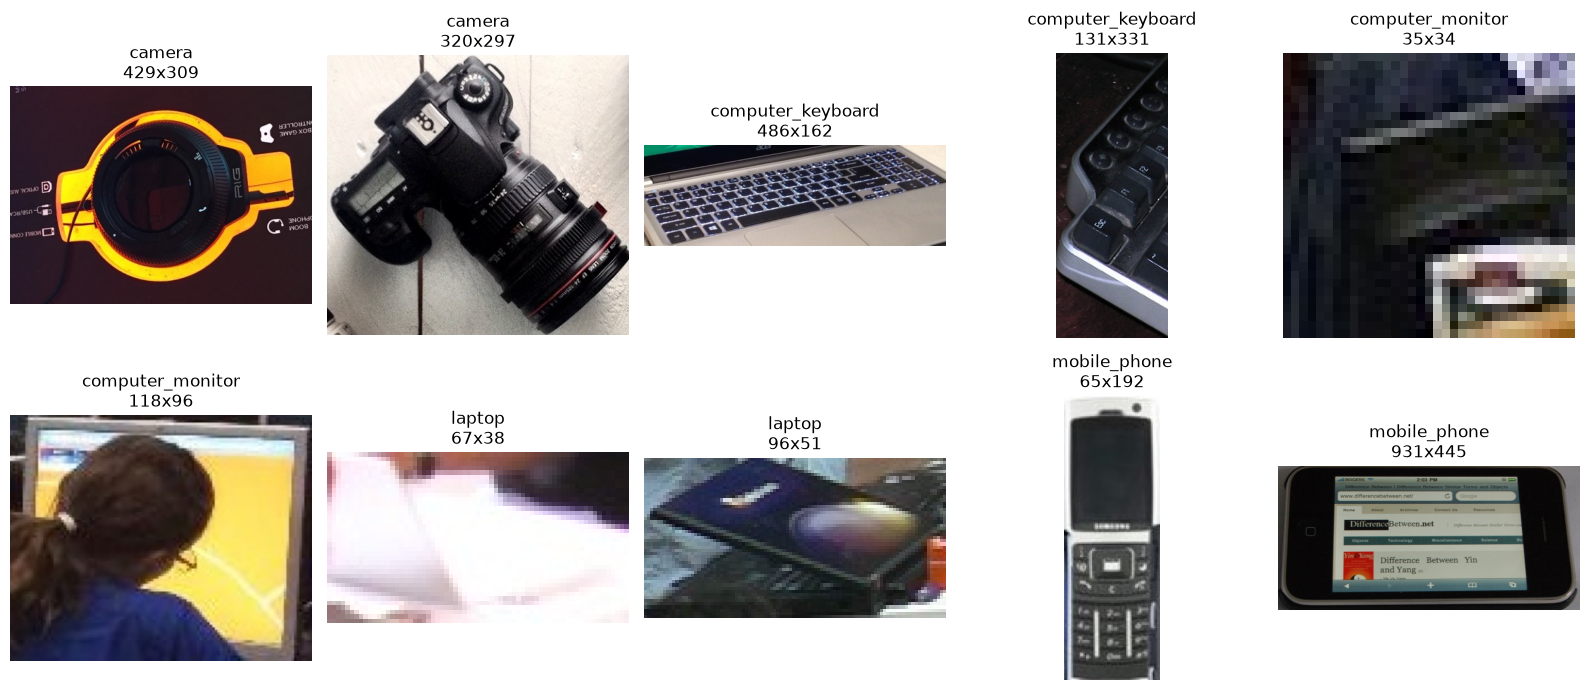

In [7]:
sample_rows = (
    split_metadata.groupby("local_label", group_keys=False)
    .sample(2, random_state=SEED)
    .reset_index(drop=True)
)
fig, axes = plt.subplots(2, len(class_names_from_config), figsize=(16, 7))
for axis, (_, row) in zip(axes.ravel(), sample_rows.iterrows()):
    image = Image.open(row["split_crop_path"]).convert("RGB")
    axis.imshow(image)
    axis.set_title(f"{row['local_label']}\n{image.width}x{image.height}")
    axis.axis("off")
plt.tight_layout()


# 9. Image Preprocessing Pipeline

Dataset dimuat dari folder hasil split manual menggunakan `tf.keras.utils.image_dataset_from_directory`. Shuffle hanya dipakai untuk train. Validation dan test tidak di-shuffle agar evaluasi dan classification report stabil.


In [8]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True,
    seed=SEED,
)

train_eval_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False,
)

validation_ds = tf.keras.utils.image_dataset_from_directory(
    VALIDATION_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False,
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False,
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)
label_text = "\n".join(class_names) + "\n"
Path("label.txt").write_text(label_text, encoding="utf-8")
(TFLITE_DIR / "label.txt").write_text(label_text, encoding="utf-8")
(TFJS_MODEL_DIR / "label.txt").write_text(label_text, encoding="utf-8")

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
train_eval_ds = train_eval_ds.prefetch(AUTOTUNE)
validation_ds = validation_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

print("class_names:", class_names)


Found 11998 files belonging to 5 classes.


I0000 00:00:1782399670.661006    8961 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1766 MB memory:  -> device: 0, name: NVIDIA RTX A500 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Found 11998 files belonging to 5 classes.


Found 1504 files belonging to 5 classes.


Found 1498 files belonging to 5 classes.


class_names: ['camera', 'computer_keyboard', 'computer_monitor', 'laptop', 'mobile_phone']


# 10. Data Augmentation

Augmentation hanya dipakai saat training (`training=True`) dan menjadi bagian dari model Sequential final. Validation dan test tetap dievaluasi tanpa augmentasi acak.


In [9]:
data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal", seed=SEED),
        tf.keras.layers.RandomRotation(0.03, seed=SEED),
        tf.keras.layers.RandomZoom(0.08, seed=SEED),
        tf.keras.layers.RandomContrast(0.1, seed=SEED),
    ],
    name="data_augmentation",
)


# 11. Final Model: Sequential + Conv2D + Pooling Eksplisit

Model final adalah `tf.keras.Sequential`. Backbone EfficientNetV2B0 dipakai sebagai feature extractor, lalu ditambahkan `Conv2D` eksplisit dan pooling eksplisit di luar backbone sesuai feedback reviewer. Model inilah yang dilatih, dievaluasi, dan diexport.


In [10]:
base_model = tf.keras.applications.EfficientNetV2B0(
    include_top=False,
    weights="imagenet",
    input_shape=(*IMG_SIZE, 3),
    include_preprocessing=True,
)
base_model.trainable = False

model = tf.keras.Sequential(
    [
        tf.keras.Input(shape=(*IMG_SIZE, 3), name="input_image"),
        data_augmentation,
        base_model,
        tf.keras.layers.Conv2D(128, 3, padding="same", activation="relu", name="explicit_conv2d_requirement"),
        tf.keras.layers.MaxPooling2D(name="explicit_pooling_requirement"),
        tf.keras.layers.GlobalAveragePooling2D(name="global_average_pooling_after_explicit_layers"),
        tf.keras.layers.Dropout(0.4, name="classifier_dropout_1"),
        tf.keras.layers.Dense(192, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(1e-4), name="classifier_dense"),
        tf.keras.layers.Dropout(0.3, name="classifier_dropout_2"),
        tf.keras.layers.Dense(NUM_CLASSES, activation="softmax", name="class_probabilities"),
    ],
    name=CLASSIFIER_NAME,
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-6),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

architecture_checks = {
    "is_tf_keras_sequential": isinstance(model, tf.keras.Sequential),
    "has_explicit_conv2d_requirement": any(layer.name == "explicit_conv2d_requirement" and isinstance(layer, tf.keras.layers.Conv2D) for layer in model.layers),
    "has_explicit_pooling_requirement": any(layer.name == "explicit_pooling_requirement" and isinstance(layer, tf.keras.layers.MaxPooling2D) for layer in model.layers),
    "final_output_classes": NUM_CLASSES,
}
print(json.dumps(architecture_checks, indent=2))
model.summary()


{
  "is_tf_keras_sequential": true,
  "has_explicit_conv2d_requirement": true,
  "has_explicit_pooling_requirement": true,
  "final_output_classes": 5
}


Model: "sequential_conv2d_pooling_it_asset_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ explicit_conv2d_requirement     │ (None, 7, 7, 128)      │     1,474,688 │
│ (Conv2D)                        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ explicit_pooling_requirement    │ (None, 3, 3, 128)      │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling_after_e… │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier_dropout_1 (Dropout)  │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier_dense (Dense)        │ (None, 192)            │        24,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier_dropout_2 (Dropout)  │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ class_probabilities (Dense)     │ (None, 5)              │           965 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,419,733 (28.30 MB)

 Trainable params: 1,500,421 (5.72 MB)

 Non-trainable params: 5,919,312 (22.58 MB)

# 12. Training dengan Callback

Model final dilatih dengan `model.fit()`. Callback yang digunakan: `ModelCheckpoint`, `EarlyStopping`, dan `ReduceLROnPlateau`. Monitor memakai validation metric, bukan test metric.

Jika checkpoint lokal dari run sebelumnya tersedia, notebook memuatnya sebagai warm start agar rerun lokal lebih cepat, lalu tetap menjalankan `model.fit()` pada model final yang sama. Jika checkpoint tidak ada, model tetap dapat dilatih dari backbone ImageNet.


In [11]:
checkpoint_path = CHECKPOINT_DIR / "best_sequential_model.weights.h5"
review_checkpoint_path = CHECKPOINT_DIR / "reviewer_visible_sequential_model.weights.h5"

if checkpoint_path.exists():
    model.load_weights(checkpoint_path)
    print(f"Loaded existing Sequential checkpoint for warm start: {checkpoint_path}")
    train_epochs = 1
else:
    print("No existing checkpoint found; training from ImageNet backbone initialization.")
    train_epochs = 8

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        review_checkpoint_path,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        save_weights_only=True,
        verbose=1,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=3,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1,
    ),
]

history = model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=train_epochs,
    callbacks=callbacks,
    verbose=1,
)

if review_checkpoint_path.exists():
    model.load_weights(review_checkpoint_path)
    print(f"Loaded best reviewer-visible checkpoint: {review_checkpoint_path}")


/home/agung/.local/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Loaded existing Sequential checkpoint for warm start: outputs/checkpoints_sequential/best_sequential_model.weights.h5


E0000 00:00:1782399687.779945    8961 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/sequential_conv2d_pooling_it_asset_classifier_1/efficientnetv2-b0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


I0000 00:00:1782399690.169846    9129 cuda_dnn.cc:529] Loaded cuDNN version 92302


  1/375 ━━━━━━━━━━━━━━━━━━━━ 1:59:24 19s/step - accuracy: 0.8438 - loss: 0.3743

...


Epoch 1: val_accuracy improved from None to 0.92753, saving model to outputs/checkpoints_sequential/reviewer_visible_sequential_model.weights.h5



Epoch 1: finished saving model to outputs/checkpoints_sequential/reviewer_visible_sequential_model.weights.h5


375/375 ━━━━━━━━━━━━━━━━━━━━ 427s 1s/step - accuracy: 0.8893 - loss: 0.3202 - val_accuracy: 0.9275 - val_loss: 0.2319 - learning_rate: 1.0000e-06


Restoring model weights from the end of the best epoch: 1.


Loaded best reviewer-visible checkpoint: outputs/checkpoints_sequential/reviewer_visible_sequential_model.weights.h5


# 13. Training History Visualization

Plot accuracy dan loss dibuat dari object `history` hasil `model.fit()` pada notebook ini.


,epoch,accuracy,loss,val_accuracy,val_loss,learning_rate
0,1,0.889315,0.320244,0.927527,0.231883,1.000000e-06


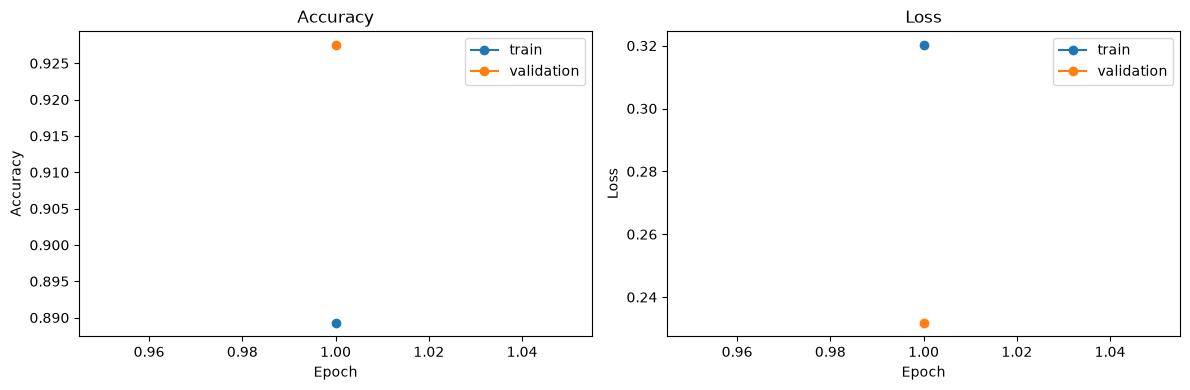

In [12]:
history_df = pd.DataFrame(history.history)
history_df.insert(0, "epoch", np.arange(1, len(history_df) + 1))
history_df.to_csv(EVALUATION_DIR / "sequential_training_history.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_df["epoch"], history_df["accuracy"], marker="o", label="train")
axes[0].plot(history_df["epoch"], history_df["val_accuracy"], marker="o", label="validation")
axes[0].set_title("Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[1].plot(history_df["epoch"], history_df["loss"], marker="o", label="train")
axes[1].plot(history_df["epoch"], history_df["val_loss"], marker="o", label="validation")
axes[1].set_title("Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
plt.tight_layout()
plt.savefig(EVALUATION_DIR / "sequential_training_history.png", dpi=150)
history_df


# 14. Evaluasi Langsung dengan model.evaluate

Akurasi train, validation, dan test dihitung langsung dari dataset TensorFlow yang diload dari folder split. File JSON/CSV hanya disimpan setelah evaluasi langsung selesai, bukan sebagai sumber utama metrik.


In [13]:
train_loss, train_accuracy = model.evaluate(train_eval_ds, verbose=1)
val_loss, val_accuracy = model.evaluate(validation_ds, verbose=1)
test_loss, test_accuracy = model.evaluate(test_ds, verbose=1)

direct_eval = {
    "train_accuracy": float(train_accuracy),
    "train_loss": float(train_loss),
    "validation_accuracy": float(val_accuracy),
    "validation_loss": float(val_loss),
    "test_accuracy": float(test_accuracy),
    "test_loss": float(test_loss),
    "minimum_required_accuracy": MINIMUM_REQUIRED_ACCURACY,
    "meets_minimum_test_accuracy": bool(test_accuracy >= MINIMUM_REQUIRED_ACCURACY),
    "target_accuracy": FIVE_STAR_TARGET_ACCURACY,
    "meets_target_test_accuracy": bool(test_accuracy >= FIVE_STAR_TARGET_ACCURACY),
}
(EVALUATION_DIR / "sequential_direct_eval.json").write_text(json.dumps(direct_eval, indent=2), encoding="utf-8")
print(json.dumps(direct_eval, indent=2))
if test_accuracy < FIVE_STAR_TARGET_ACCURACY:
    print("Target bintang 5 belum aman karena test accuracy masih di bawah 95%. Rekomendasi: lanjutkan fine-tuning bertahap memakai validation set, bukan test set.")


  1/375 ━━━━━━━━━━━━━━━━━━━━ 5:54 948ms/step - accuracy: 0.9375 - loss: 0.2204

  2/375 ━━━━━━━━━━━━━━━━━━━━ 5:14 843ms/step - accuracy: 0.9453 - loss: 0.1898

  3/375 ━━━━━━━━━━━━━━━━━━━━ 5:14 846ms/step - accuracy: 0.9497 - loss: 0.1753

  4/375 ━━━━━━━━━━━━━━━━━━━━ 5:15 851ms/step - accuracy: 0.9447 - loss: 0.1846

  5/375 ━━━━━━━━━━━━━━━━━━━━ 5:14 850ms/step - accuracy: 0.9420 - loss: 0.1858

...

45/47 ━━━━━━━━━━━━━━━━━━━━ 1s 854ms/step - accuracy: 0.9621 - loss: 0.1541

46/47 ━━━━━━━━━━━━━━━━━━━━ 0s 854ms/step - accuracy: 0.9617 - loss: 0.1553

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 961ms/step - accuracy: 0.9613 - loss: 0.1566

47/47 ━━━━━━━━━━━━━━━━━━━━ 45s 962ms/step - accuracy: 0.9439 - loss: 0.2143


{
  "train_accuracy": 0.9293215274810791,
  "train_loss": 0.23165565729141235,
  "validation_accuracy": 0.927526593208313,
  "validation_loss": 0.23188288509845734,
  "test_accuracy": 0.9439252614974976,
  "test_loss": 0.2143460363149643,
  "minimum_required_accuracy": 0.85,
  "meets_minimum_test_accuracy": true,
  "target_accuracy": 0.95,
  "meets_target_test_accuracy": false
}
Target bintang 5 belum aman karena test accuracy masih di bawah 95%. Rekomendasi: lanjutkan fine-tuning bertahap memakai validation set, bukan test set.


# 15. Classification Report dan Confusion Matrix dari test_ds

Classification report dan confusion matrix dihitung langsung dari `model.predict(test_ds)` pada run notebook ini, kemudian hasilnya disimpan ke `outputs/evaluation/`.


 1/47 ━━━━━━━━━━━━━━━━━━━━ 4:26 6s/step

 2/47 ━━━━━━━━━━━━━━━━━━━━ 38s 847ms/step

 3/47 ━━━━━━━━━━━━━━━━━━━━ 37s 845ms/step

 4/47 ━━━━━━━━━━━━━━━━━━━━ 36s 841ms/step

 5/47 ━━━━━━━━━━━━━━━━━━━━ 35s 844ms/step

...

46/47 ━━━━━━━━━━━━━━━━━━━━ 0s 853ms/step

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 952ms/step

47/47 ━━━━━━━━━━━━━━━━━━━━ 50s 953ms/step


2026-06-25 22:16:12.993017: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


,precision,recall,f1-score,support
camera,0.973064,0.963333,0.968174,300.000000
computer_keyboard,0.931034,0.990000,0.959612,300.000000
computer_monitor,0.936667,0.942953,0.939799,298.000000
laptop,0.936170,0.880000,0.907216,300.000000
mobile_phone,0.943333,0.943333,0.943333,300.000000
accuracy,0.943925,0.943925,0.943925,0.943925
macro avg,0.944054,0.943924,0.943627,1498.000000
weighted avg,0.944064,0.943925,0.943632,1498.000000


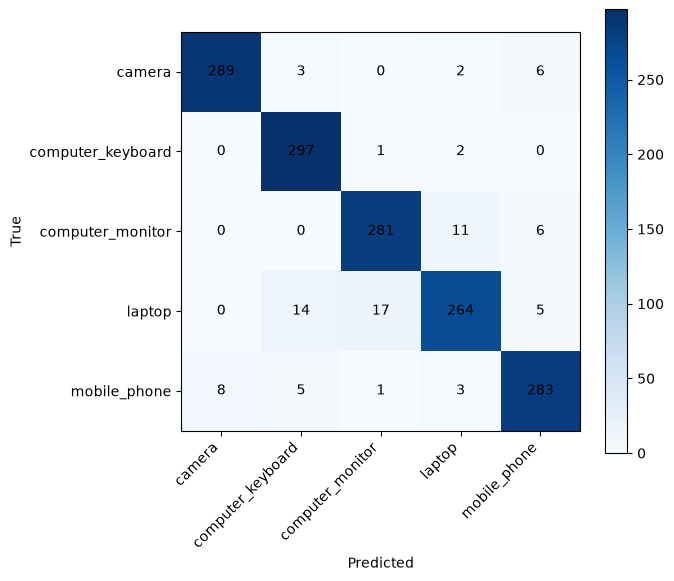

In [14]:
y_prob = model.predict(test_ds, verbose=1)
y_pred = np.argmax(y_prob, axis=1)
y_true = np.concatenate([np.argmax(labels.numpy(), axis=1) for _, labels in test_ds], axis=0)

report_dict = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0,
)
classification_report_df = pd.DataFrame(report_dict).transpose()
confusion_matrix_df = pd.DataFrame(
    confusion_matrix(y_true, y_pred),
    index=class_names,
    columns=class_names,
)
classification_report_df.to_csv(EVALUATION_DIR / "sequential_classification_report.csv")
confusion_matrix_df.to_csv(EVALUATION_DIR / "sequential_confusion_matrix.csv")

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(confusion_matrix_df.values, cmap="Blues")
ax.set_xticks(np.arange(len(class_names)), labels=class_names, rotation=45, ha="right")
ax.set_yticks(np.arange(len(class_names)), labels=class_names)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
for row_index in range(len(class_names)):
    for col_index in range(len(class_names)):
        ax.text(col_index, row_index, int(confusion_matrix_df.iloc[row_index, col_index]), ha="center", va="center")
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(EVALUATION_DIR / "sequential_confusion_matrix.png", dpi=150)
classification_report_df


# 16. Export Model dari Model Final yang Sama

SavedModel, TFLite, dan TFJS diexport dari object `model` yang sama dengan model yang dilatih dan dievaluasi di atas. Label file disamakan di root, folder TFLite, dan folder TFJS.


In [15]:
def clean_directory(path: Path) -> None:
    if path.exists():
        shutil.rmtree(path)
    path.mkdir(parents=True, exist_ok=True)


def patch_tfjs_imports() -> None:
    import numpy as tfjs_numpy
    if not hasattr(tfjs_numpy, "object"):
        tfjs_numpy.object = object
    if not hasattr(tfjs_numpy, "bool"):
        tfjs_numpy.bool = bool
    for prefix in ["tensorflow_decision_forests", "tensorflow_hub"]:
        for module_name in list(sys.modules):
            if module_name.startswith(prefix):
                sys.modules.pop(module_name)
    for module_name in ["tensorflow_decision_forests", "tensorflow_hub"]:
        stub = types.ModuleType(module_name)
        stub.__spec__ = importlib.machinery.ModuleSpec(module_name, loader=None)
        sys.modules[module_name] = stub


clean_directory(SAVED_MODEL_DIR)
if hasattr(model, "export"):
    model.export(str(SAVED_MODEL_DIR))
else:
    tf.saved_model.save(model, str(SAVED_MODEL_DIR))

converter = tf.lite.TFLiteConverter.from_keras_model(model)
try:
    tflite_model = converter.convert()
except Exception as first_error:
    print("Default TFLite conversion failed, retrying with SELECT_TF_OPS:", repr(first_error))
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS, tf.lite.OpsSet.SELECT_TF_OPS]
    tflite_model = converter.convert()

tflite_model_path = TFLITE_DIR / "it_asset_classifier.tflite"
tflite_model_path.write_bytes(tflite_model)
Path("label.txt").write_text(label_text, encoding="utf-8")
(TFLITE_DIR / "label.txt").write_text(label_text, encoding="utf-8")

clean_directory(TFJS_MODEL_DIR)
tfjs_status = "not_exported"
tfjs_error = None
try:
    patch_tfjs_imports()
    from tensorflowjs.converters import save_keras_model
    save_keras_model(model, str(TFJS_MODEL_DIR))
    (TFJS_MODEL_DIR / "label.txt").write_text(label_text, encoding="utf-8")
    tfjs_status = "exported"
except Exception as error:
    tfjs_error = repr(error)
    print("TFJS export error:", tfjs_error)

print("SavedModel:", SAVED_MODEL_DIR)
print("TFLite:", tflite_model_path)
print("TFJS status:", tfjs_status)


INFO:tensorflow:Assets written to: saved_model/it_asset_classifier/assets


INFO:tensorflow:Assets written to: saved_model/it_asset_classifier/assets


Saved artifact at 'saved_model/it_asset_classifier'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_image')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  131433207169296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131433207170064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131433207170640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131433207169680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131433207172176: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  131433207171600: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  131433207169872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131433207174480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131433207175056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131433207173904: TensorSpec(shape=(), dtype=tf.resou

INFO:tensorflow:Assets written to: /tmp/tmpcdx6myx2/assets


INFO:tensorflow:Assets written to: /tmp/tmpcdx6myx2/assets


Saved artifact at '/tmp/tmpcdx6myx2'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_image')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  131433207172176: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  131433207171600: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  131433207169872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131433207174480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131433207175056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131433207173904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131433207174672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131433207173712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131433207174864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131433207174096: TensorSpec(shape=(), dtype=tf.resource, name=None)

W0000 00:00:1782400623.052140    8961 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1782400623.052188    8961 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


/tmp/ipykernel_8961/4050960725.py:9: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(tfjs_numpy, "object"):


failed to lookup keras version from the file,
    this is likely a weight only file


SavedModel: saved_model/it_asset_classifier
TFLite: tflite/it_asset_classifier.tflite
TFJS status: exported


# 17. Export Validation

Export divalidasi langsung di notebook: SavedModel bisa diload, TFLite interpreter bisa allocate tensor dan menghasilkan output shape sesuai jumlah kelas, TFJS `model.json` dan shard `.bin` tersedia, serta label files konsisten.


In [16]:
def infer_tfjs_output_classes(model_json: dict) -> int | None:
    signature = model_json.get("signature") or model_json.get("modelTopology", {}).get("signature", {})
    for output_info in signature.get("outputs", {}).values():
        dims = output_info.get("tensorShape", {}).get("dim", [])
        if dims and dims[-1].get("size") is not None:
            return int(dims[-1]["size"])
    model_config = model_json.get("modelTopology", {}).get("model_config", {})
    layers = model_config.get("config", {}).get("layers", [])
    for layer in reversed(layers):
        if layer.get("class_name") == "Dense":
            units = layer.get("config", {}).get("units")
            return int(units) if units is not None else None
    return None


sample_images, _ = next(iter(test_ds.take(1)))
sample_one = tf.cast(sample_images[:1], tf.float32)
keras_prediction = model(sample_one, training=False).numpy()

loaded_saved_model = tf.saved_model.load(str(SAVED_MODEL_DIR))
saved_model_output = next(iter(loaded_saved_model.signatures["serving_default"](sample_one).values())).numpy()

interpreter = tf.lite.Interpreter(model_path=str(tflite_model_path))
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()
interpreter.set_tensor(input_details[0]["index"], sample_one.numpy().astype(input_details[0]["dtype"]))
interpreter.invoke()
tflite_output = interpreter.get_tensor(output_details[0]["index"])

label_files = {
    "root": Path("label.txt").read_text(encoding="utf-8").splitlines(),
    "tflite": (TFLITE_DIR / "label.txt").read_text(encoding="utf-8").splitlines(),
    "tfjs": (TFJS_MODEL_DIR / "label.txt").read_text(encoding="utf-8").splitlines() if (TFJS_MODEL_DIR / "label.txt").exists() else [],
}
model_json_path = TFJS_MODEL_DIR / "model.json"
tfjs_shards = sorted(TFJS_MODEL_DIR.glob("group*.bin"))
tfjs_output_classes = None
if model_json_path.exists():
    tfjs_output_classes = infer_tfjs_output_classes(json.loads(model_json_path.read_text(encoding="utf-8")))

export_summary = {
    "model": CLASSIFIER_NAME,
    "saved_model_status": "exported_and_validated" if (SAVED_MODEL_DIR / "saved_model.pb").exists() else "missing",
    "saved_model_dir": SAVED_MODEL_DIR.as_posix(),
    "saved_model_prediction_shape": list(saved_model_output.shape),
    "saved_model_prediction_sum": float(saved_model_output.sum()),
    "saved_model_max_delta_vs_keras": float(np.max(np.abs(saved_model_output - keras_prediction))),
    "tflite_status": "exported_and_validated",
    "tflite_model_path": tflite_model_path.as_posix(),
    "tflite_prediction_shape": list(tflite_output.shape),
    "tflite_prediction_sum": float(tflite_output.sum()),
    "tflite_max_delta_vs_keras": float(np.max(np.abs(tflite_output - keras_prediction))),
    "tfjs_status": "exported_and_validated" if model_json_path.exists() and len(tfjs_shards) > 0 and tfjs_error is None else "failed",
    "tfjs_error": tfjs_error,
    "tfjs_model_dir": TFJS_MODEL_DIR.as_posix(),
    "tfjs_output_classes": tfjs_output_classes,
    "tfjs_file_count": len([path for path in TFJS_MODEL_DIR.glob("*") if path.is_file()]),
    "label_files_match": label_files["root"] == label_files["tflite"] == label_files["tfjs"] == class_names,
}
(EXPORT_DIR / "it_asset_export_summary.json").write_text(json.dumps(export_summary, indent=2), encoding="utf-8")
print(json.dumps(export_summary, indent=2))


/home/agung/.local/lib/python3.12/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


{
  "model": "sequential_conv2d_pooling_it_asset_classifier",
  "saved_model_status": "exported_and_validated",
  "saved_model_dir": "saved_model/it_asset_classifier",
  "saved_model_prediction_shape": [
    1,
    5
  ],
  "saved_model_prediction_sum": 1.0,
  "saved_model_max_delta_vs_keras": 3.814697265625e-06,
  "tflite_status": "exported_and_validated",
  "tflite_model_path": "tflite/it_asset_classifier.tflite",
  "tflite_prediction_shape": [
    1,
    5
  ],
  "tflite_prediction_sum": 0.9999998807907104,
  "tflite_max_delta_vs_keras": 1.1920928955078125e-07,
  "tfjs_status": "exported_and_validated",
  "tfjs_error": null,
  "tfjs_model_dir": "tfjs/it_asset_classifier",
  "tfjs_output_classes": 5,
  "tfjs_file_count": 10,
  "label_files_match": true
}


# 18. Inference Proof

Sample inference diambil dari `test_ds`/metadata test split. Notebook menampilkan gambar, true label, predicted label, dan confidence dari model final.


,image_path,true_label,predicted_label,confidence
0,dataset/submission_split/test/camera/camera_tr...,camera,camera,0.786560
1,dataset/submission_split/test/computer_keyboar...,computer_keyboard,computer_keyboard,0.989502
2,dataset/submission_split/test/computer_monitor...,computer_monitor,computer_monitor,0.697433
3,dataset/submission_split/test/laptop/laptop_tr...,laptop,laptop,0.912695
4,dataset/submission_split/test/mobile_phone/mob...,mobile_phone,mobile_phone,0.993444


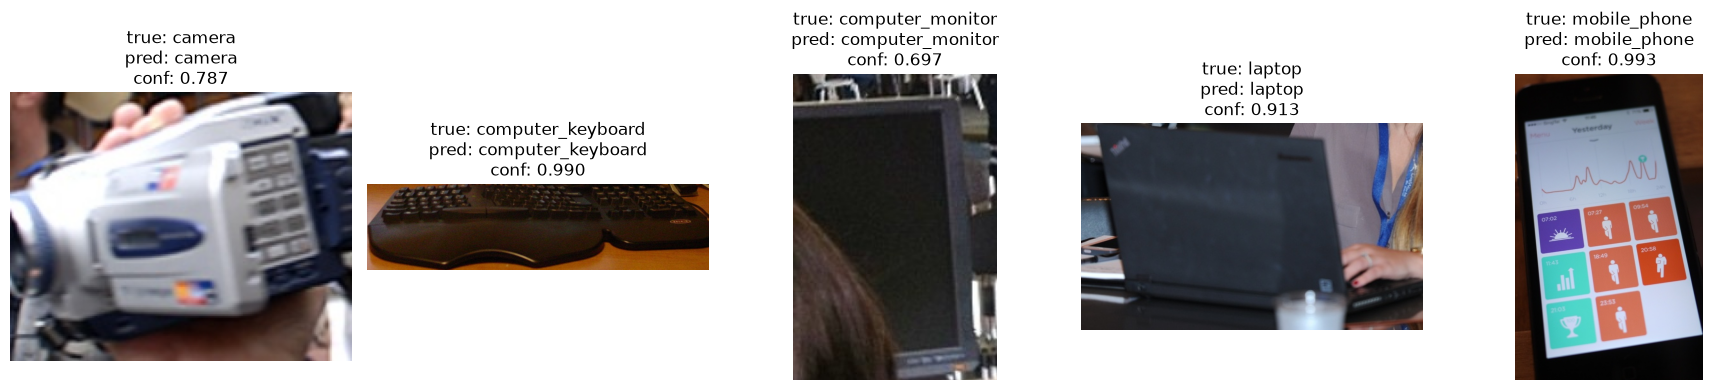

In [17]:
sample_records = []
fig, axes = plt.subplots(1, len(class_names), figsize=(18, 4))
for axis, label in zip(axes, class_names):
    row = split_metadata[(split_metadata["local_split"] == "test") & (split_metadata["local_label"] == label)].sample(1, random_state=SEED).iloc[0]
    image = Image.open(row["split_crop_path"]).convert("RGB")
    array = np.asarray(image.resize(IMG_SIZE), dtype=np.float32)[None, ...]
    probabilities = model(array, training=False).numpy()[0]
    predicted_index = int(np.argmax(probabilities))
    record = {
        "image_path": row["split_crop_path"],
        "true_label": label,
        "predicted_label": class_names[predicted_index],
        "confidence": float(probabilities[predicted_index]),
    }
    sample_records.append(record)
    axis.imshow(image)
    axis.set_title(f"true: {label}\npred: {record['predicted_label']}\nconf: {record['confidence']:.3f}")
    axis.axis("off")
plt.tight_layout()
plt.savefig(EVALUATION_DIR / "sequential_inference_proof.png", dpi=150)
sample_inference_df = pd.DataFrame(sample_records)
sample_inference_df.to_csv(EVALUATION_DIR / "sequential_inference_proof.csv", index=False)
sample_inference_df


# 19. Kesimpulan

Notebook ini memperlihatkan rantai reproducible untuk reviewer:

1. sumber dataset Open Images V7 detection crops di `dataset/raw/<class_name>/`;
2. split manual eksplisit ke `dataset/submission_split/train|validation|test` dengan seed `42`;
3. load dataset dari hasil split notebook;
4. model final `tf.keras.Sequential` dengan `Conv2D` dan pooling eksplisit;
5. training dengan `model.fit()` dan callback;
6. evaluasi langsung `model.evaluate(train_ds)`, `model.evaluate(validation_ds)`, dan `model.evaluate(test_ds)`;
7. classification report dan confusion matrix langsung dari `model.predict(test_ds)`;
8. export SavedModel, TFLite, dan TFJS dari model yang sama;
9. validasi export dan inference proof.

Jika test accuracy berada di bawah 95%, target minimal Dicoding tetap dicek terhadap 85%, tetapi target bintang 5 belum aman dan tuning lanjutan perlu dilakukan hanya dengan validation set.
